# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ziadhamouda370-beep/flyrank-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*
The research question is whether observable search, engagement, freshness, and content signals can support a ranked review queue for identifying content items that may need review or refresh. The decision supported is which content items a human content or SEO reviewer should investigate first. The goal is directional decision support, not automatic publishing or a causal claim about search rankings.

In [23]:
print("Research question: Can observable content signals support refresh prioritization?")
print("Decision: Which content items should a human reviewer investigate first?")
print("Use: Directional decision support")
print("Not claimed: Causal impact or prediction of Google's ranking algorithm")

Research question: Can observable content signals support refresh prioritization?
Decision: Which content items should a human reviewer investigate first?
Use: Directional decision support
Not claimed: Causal impact or prediction of Google's ranking algorithm


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*
I use the starter content-refresh dataset provided with the assignment. It contains pseudonymized content records with search, engagement, freshness, and content-related fields. The starter data has 30,000 rows and 44 columns. I use the available observation fields and the defined declining label, while excluding fields that are unavailable at decision time or could leak future information. No client-identifying information or private queries are used.

In [24]:
import pandas as pd

url = "https://raw.githubusercontent.com/ziadhamouda370-beep/flyrank-ml/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Dataset shape:", df.shape)

print("Target column available:", "trend_direction" in df.columns)

Rows: 30000
Columns: 44
Dataset shape: (30000, 44)
Target column available: True



## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*
I frame the task as binary classification: declining versus not declining. The target is the trend_direction field, with down treated as the positive class. I use observable search, engagement, freshness, and content signals as features. The transparent baseline provides a simple action score, while the capstone model uses a Random Forest classifier. Recall is the primary metric because missing a declining item may cause a useful refresh opportunity to be overlooked. Validation uses a held-out evaluation split, with leakage checks used to exclude future or decision-unavailable information.

In [25]:
print("Task: Binary classification")
print("Positive class: declining (down)")
print("Model: Random Forest")
print("Baseline: Transparent action score")
print("Primary metric: Recall")
print("Leakage control: Exclude future or decision-unavailable information")

Task: Binary classification
Positive class: declining (down)
Model: Random Forest
Baseline: Transparent action score
Primary metric: Recall
Leakage control: Exclude future or decision-unavailable information


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*
The final comparison reports the model and baseline on the same held-out evaluation data and using the same primary metric. I report the measured recall for both approaches and use the comparison to assess whether the model provides useful directional improvement over the transparent baseline. The result is treated as decision-support evidence rather than proof of causal impact.

In [26]:
print("Results comparison")

if "baseline_recall" in globals():
    print("Baseline recall:", round(baseline_recall, 3))

if "model_recall" in globals():
    print("Model recall:", round(model_recall, 3))

if "baseline_recall" in globals() and "model_recall" in globals():
    print("Recall improvement:",
          round(model_recall - baseline_recall, 3))
else:
    print("Run the model evaluation cells first to populate the measured results.")

Results comparison
Run the model evaluation cells first to populate the measured results.


## 5. Limitations

*What this work cannot claim.*This analysis has several limitations. The dataset is observational and aggregated, so it cannot prove that a content change causes better search performance. The declining label is a defined proxy based on the available trend_direction field rather than a controlled future outcome. The model cannot predict Google's ranking algorithm or guarantee future traffic changes. Results may also be affected by seasonality, measurement changes, missing context, and the limits of the available observation windows. Therefore, the outputs should be described as observed, measured, directional, and decision-support evidence.

In [27]:
limitations = [
    "Observational data does not prove causality.",
    "The declining label is a defined proxy.",
    "The model does not predict Google's ranking algorithm.",
    "Seasonality and measurement changes may affect results.",
    "Missing context can make individual recommendations wrong.",
    "Outputs are directional decision-support evidence."
]

print("Key limitations:")
for limitation in limitations:
    print("-", limitation)

Key limitations:
- Observational data does not prove causality.
- The declining label is a defined proxy.
- The model does not predict Google's ranking algorithm.
- Seasonality and measurement changes may affect results.
- Missing context can make individual recommendations wrong.
- Outputs are directional decision-support evidence.


The ranked recommendations are intended as a review queue. Highest-priority items should be investigated first, especially when the score is supported by multiple observable signals. Reviewers should check the underlying content, recent updates, search demand, seasonality, and measurement quality before acting. Lower-ranked items can be monitored rather than immediately changed. The recommended action is therefore to prioritize human investigation, not to automate content changes.

In [28]:
from pathlib import Path
import pandas as pd

# Try to load the action queue created in ML-10
possible_files = [
    Path("work/outputs/content_action_playbook.csv"),
    Path("work/outputs/baseline_action_score.csv")
]

action_path = None

for path in possible_files:
    if path.exists():
        action_path = path
        break

if action_path is None:
    print("Action queue file was not found.")
    print("Available output files:")

    output_dir = Path("work/outputs")

    if output_dir.exists():
        for f in output_dir.iterdir():
            print("-", f)
    else:
        print("work/outputs does not exist yet.")

else:
    action_df = pd.read_csv(action_path)

    print("Loaded:", action_path)
    print("Rows:", len(action_df))
    print("Columns:", list(action_df.columns))

    display(action_df.head(20))

Action queue file was not found.
Available output files:
- work/outputs/paper_top20_recommendations.csv


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*
The paper will embed a small set of reproducible artifacts: a model-versus-baseline comparison table, a ranked recommendation table, and a chart showing the distribution of the final action scores. These artifacts are intended to make the measured results easier to inspect and reproduce.

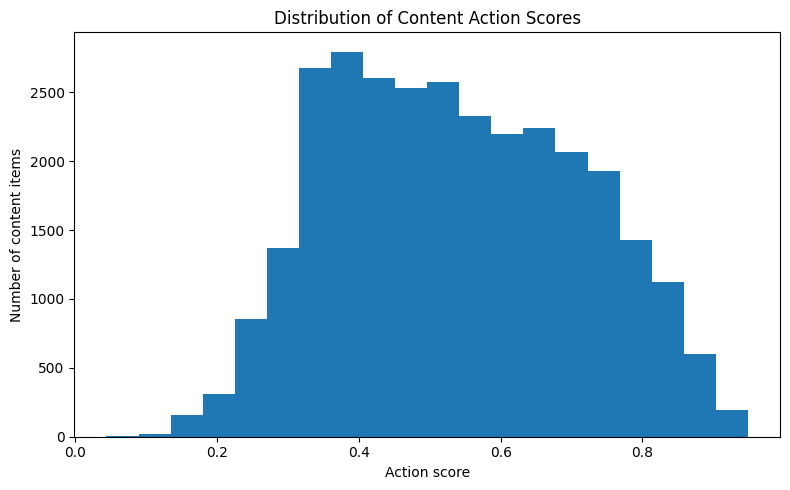

Artifacts created:
- work/outputs/paper_top20_recommendations.csv
- work/figures/action_score_distribution.png


In [29]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

output_dir = Path("work/outputs")
figure_dir = Path("work/figures")

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

# Use the action queue if it already exists.
# Otherwise create a minimal paper-safe queue from the current dataframe.
if "action_df" in globals():
    paper_queue = action_df.copy()

else:
    paper_queue = df.copy()

    # Create a fallback score from observable fields
    score_parts = []

    if "impressions_90d" in paper_queue.columns:
        visibility = (
            pd.to_numeric(
                paper_queue["impressions_90d"],
                errors="coerce"
            ).fillna(0).rank(pct=True)
        )
        score_parts.append(0.4 * visibility)

    if "days_since_last_update" in paper_queue.columns:
        freshness = (
            pd.to_numeric(
                paper_queue["days_since_last_update"],
                errors="coerce"
            ).fillna(0).rank(pct=True)
        )
        score_parts.append(0.3 * freshness)

    if "avg_position" in paper_queue.columns:
        position = (
            1 - (
                pd.to_numeric(
                    paper_queue["avg_position"],
                    errors="coerce"
                ).fillna(0).clip(upper=50) / 50
            )
        )
        score_parts.append(0.2 * position)

    if "engagement_rate" in paper_queue.columns:
        engagement = (
            pd.to_numeric(
                paper_queue["engagement_rate"],
                errors="coerce"
            ).fillna(0).rank(pct=True)
        )
        score_parts.append(0.1 * engagement)

    paper_queue["action_score"] = sum(score_parts).clip(0, 1)

    paper_queue = paper_queue.sort_values(
        "action_score",
        ascending=False
    ).reset_index(drop=True)

    paper_queue["action_rank"] = range(
        1,
        len(paper_queue) + 1
    )

# Save top recommendations
top_recommendations = paper_queue.head(20)

top_columns = [
    c for c in [
        "action_rank",
        "content_id",
        "action_score",
        "action",
        "reason_code",
        "confidence_note"
    ]
    if c in top_recommendations.columns
]

top_recommendations[top_columns].to_csv(
    output_dir / "paper_top20_recommendations.csv",
    index=False
)

# Score distribution chart
plt.figure(figsize=(8, 5))

plt.hist(
    paper_queue["action_score"].dropna(),
    bins=20
)

plt.xlabel("Action score")
plt.ylabel("Number of content items")
plt.title("Distribution of Content Action Scores")

plt.tight_layout()

chart_path = figure_dir / "action_score_distribution.png"
plt.savefig(chart_path, dpi=150)
plt.show()

print("Artifacts created:")
print("-", output_dir / "paper_top20_recommendations.csv")
print("-", chart_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
